In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# GenEval
methods = ["SD-1.5", "SPM_reproduce", "CoDE", "SPM_reproduce linear CoDE (0.5)"]
metrics = ["PickScore", "HPSv2", "CLIPScore", "GenEval", "CLIP-IQA", "DeQA" ]
data_dict = {
    "SD-1.5": {
        "PickScore": 21.627,
        "HPSv2": 0.2772,
        "ImageReward": -0.1859,
        "CLIPScore": 31.97,
        "GenEval": 0.4180,
        "CLIP-IQA": 0.6945,
        "DeQA": 3.758
    },
    "SPM_reproduce": {
        "PickScore": 21.856,
        "HPSv2": 0.2826,
        "ImageReward": 0.1834,
        "CLIPScore": 32.25,
        "GenEval": 0.4681,
        "CLIP-IQA": 0.6245,
        "DeQA": 3.291
    },
    "CoDE": {
        "PickScore": 21.676,
        "HPSv2": 0.2778,
        "ImageReward": -0.1894,
        "CLIPScore": 31.92,
        "GenEval": 0.4272,
        "CLIP-IQA": 0.6964,
        "DeQA": 3.810
    },
    "SPM_reproduce linear CoDE (0.5)": {
        "PickScore": 21.866,
        "HPSv2": 0.2817,
        "ImageReward": 0.0304,
        "CLIPScore": 32.14,
        "GenEval": 0.4615,
        "CLIP-IQA": 0.6760,
        "DeQA": 3.637
    }
}

# Pick-a-pic (lora_weight: 1.0)
methods = ["SD-1.5", "SPM_reproduce", "CoDE_15", "SPM_reproduce concat CoDE_15 (1.0)"]
metrics = ["PickScore", "HPSv2", "CLIPScore", "GenEval", "CLIP-IQA", "DeQA" ]
data_dict = {
    "SD-1.5": {
        "PickScore": 20.526,
        "HPSv2": 0.2671,
        "ImageReward": 0.1131,
        "CLIPScore": 31.55,
        "GenEval": 0.4180,
        "CLIP-IQA": 0.6593,
        "DeQA": 3.528
    },
    "SPM_reproduce": {
        "PickScore": 21.092,
        "HPSv2": 0.2752,
        "ImageReward": 0.5343,
        "CLIPScore": 32.06,
        "GenEval": 0.4681,
        "CLIP-IQA": 0.5918,
        "DeQA": 3.276
    },
    "CoDE_15": {
        "PickScore": 20.597,
        "HPSv2": 0.2671,
        "ImageReward": 0.1586,
        "CLIPScore": 31.77,
        "GenEval": 0.4248,
        "CLIP-IQA": 0.6737,
        "DeQA": 3.564
    },
    "SPM_reproduce concat CoDE_15 (1.0)": {
        "PickScore": 21.135,
        "HPSv2": 0.2750,
        "ImageReward": 0.5184,
        "CLIPScore": 32.08,
        "GenEval": 0.4703,
        "CLIP-IQA": 0.6072,
        "DeQA": 3.346
    }
}

# Pick-a-pic (lora_weight: 0.5)
methods = ["SD-1.5", "SPM_reproduce", "CoDE_15", "SPM_reproduce concat CoDE_15 (0.5)"]
metrics = ["PickScore", "HPSv2", "CLIPScore", "GenEval", "CLIP-IQA", "DeQA" ]
data_dict = {
    "SD-1.5": {
        "PickScore": 20.526,
        "HPSv2": 0.2671,
        "ImageReward": 0.1131,
        "CLIPScore": 31.55,
        "GenEval": 0.4180,
        "CLIP-IQA": 0.6593,
        "DeQA": 3.528
    },
    "SPM_reproduce": {
        "PickScore": 21.092,
        "HPSv2": 0.2752,
        "ImageReward": 0.5343,
        "CLIPScore": 32.06,
        "GenEval": 0.4681,
        "CLIP-IQA": 0.5918,
        "DeQA": 3.276
    },
    "CoDE_15": {
        "PickScore": 20.597,
        "HPSv2": 0.2671,
        "ImageReward": 0.1586,
        "CLIPScore": 31.77,
        "GenEval": 0.4248,
        "CLIP-IQA": 0.6737,
        "DeQA": 3.564
    },
    "SPM_reproduce concat CoDE_15 (0.5)": {
        "PickScore": 20.898,
        "HPSv2": 0.2720,
        "ImageReward": 0.3565,
        "CLIPScore": 32.21,
        "GenEval": 0.4681,
        "CLIP-IQA": 0.6451,
        "DeQA": 3.479
    }
}

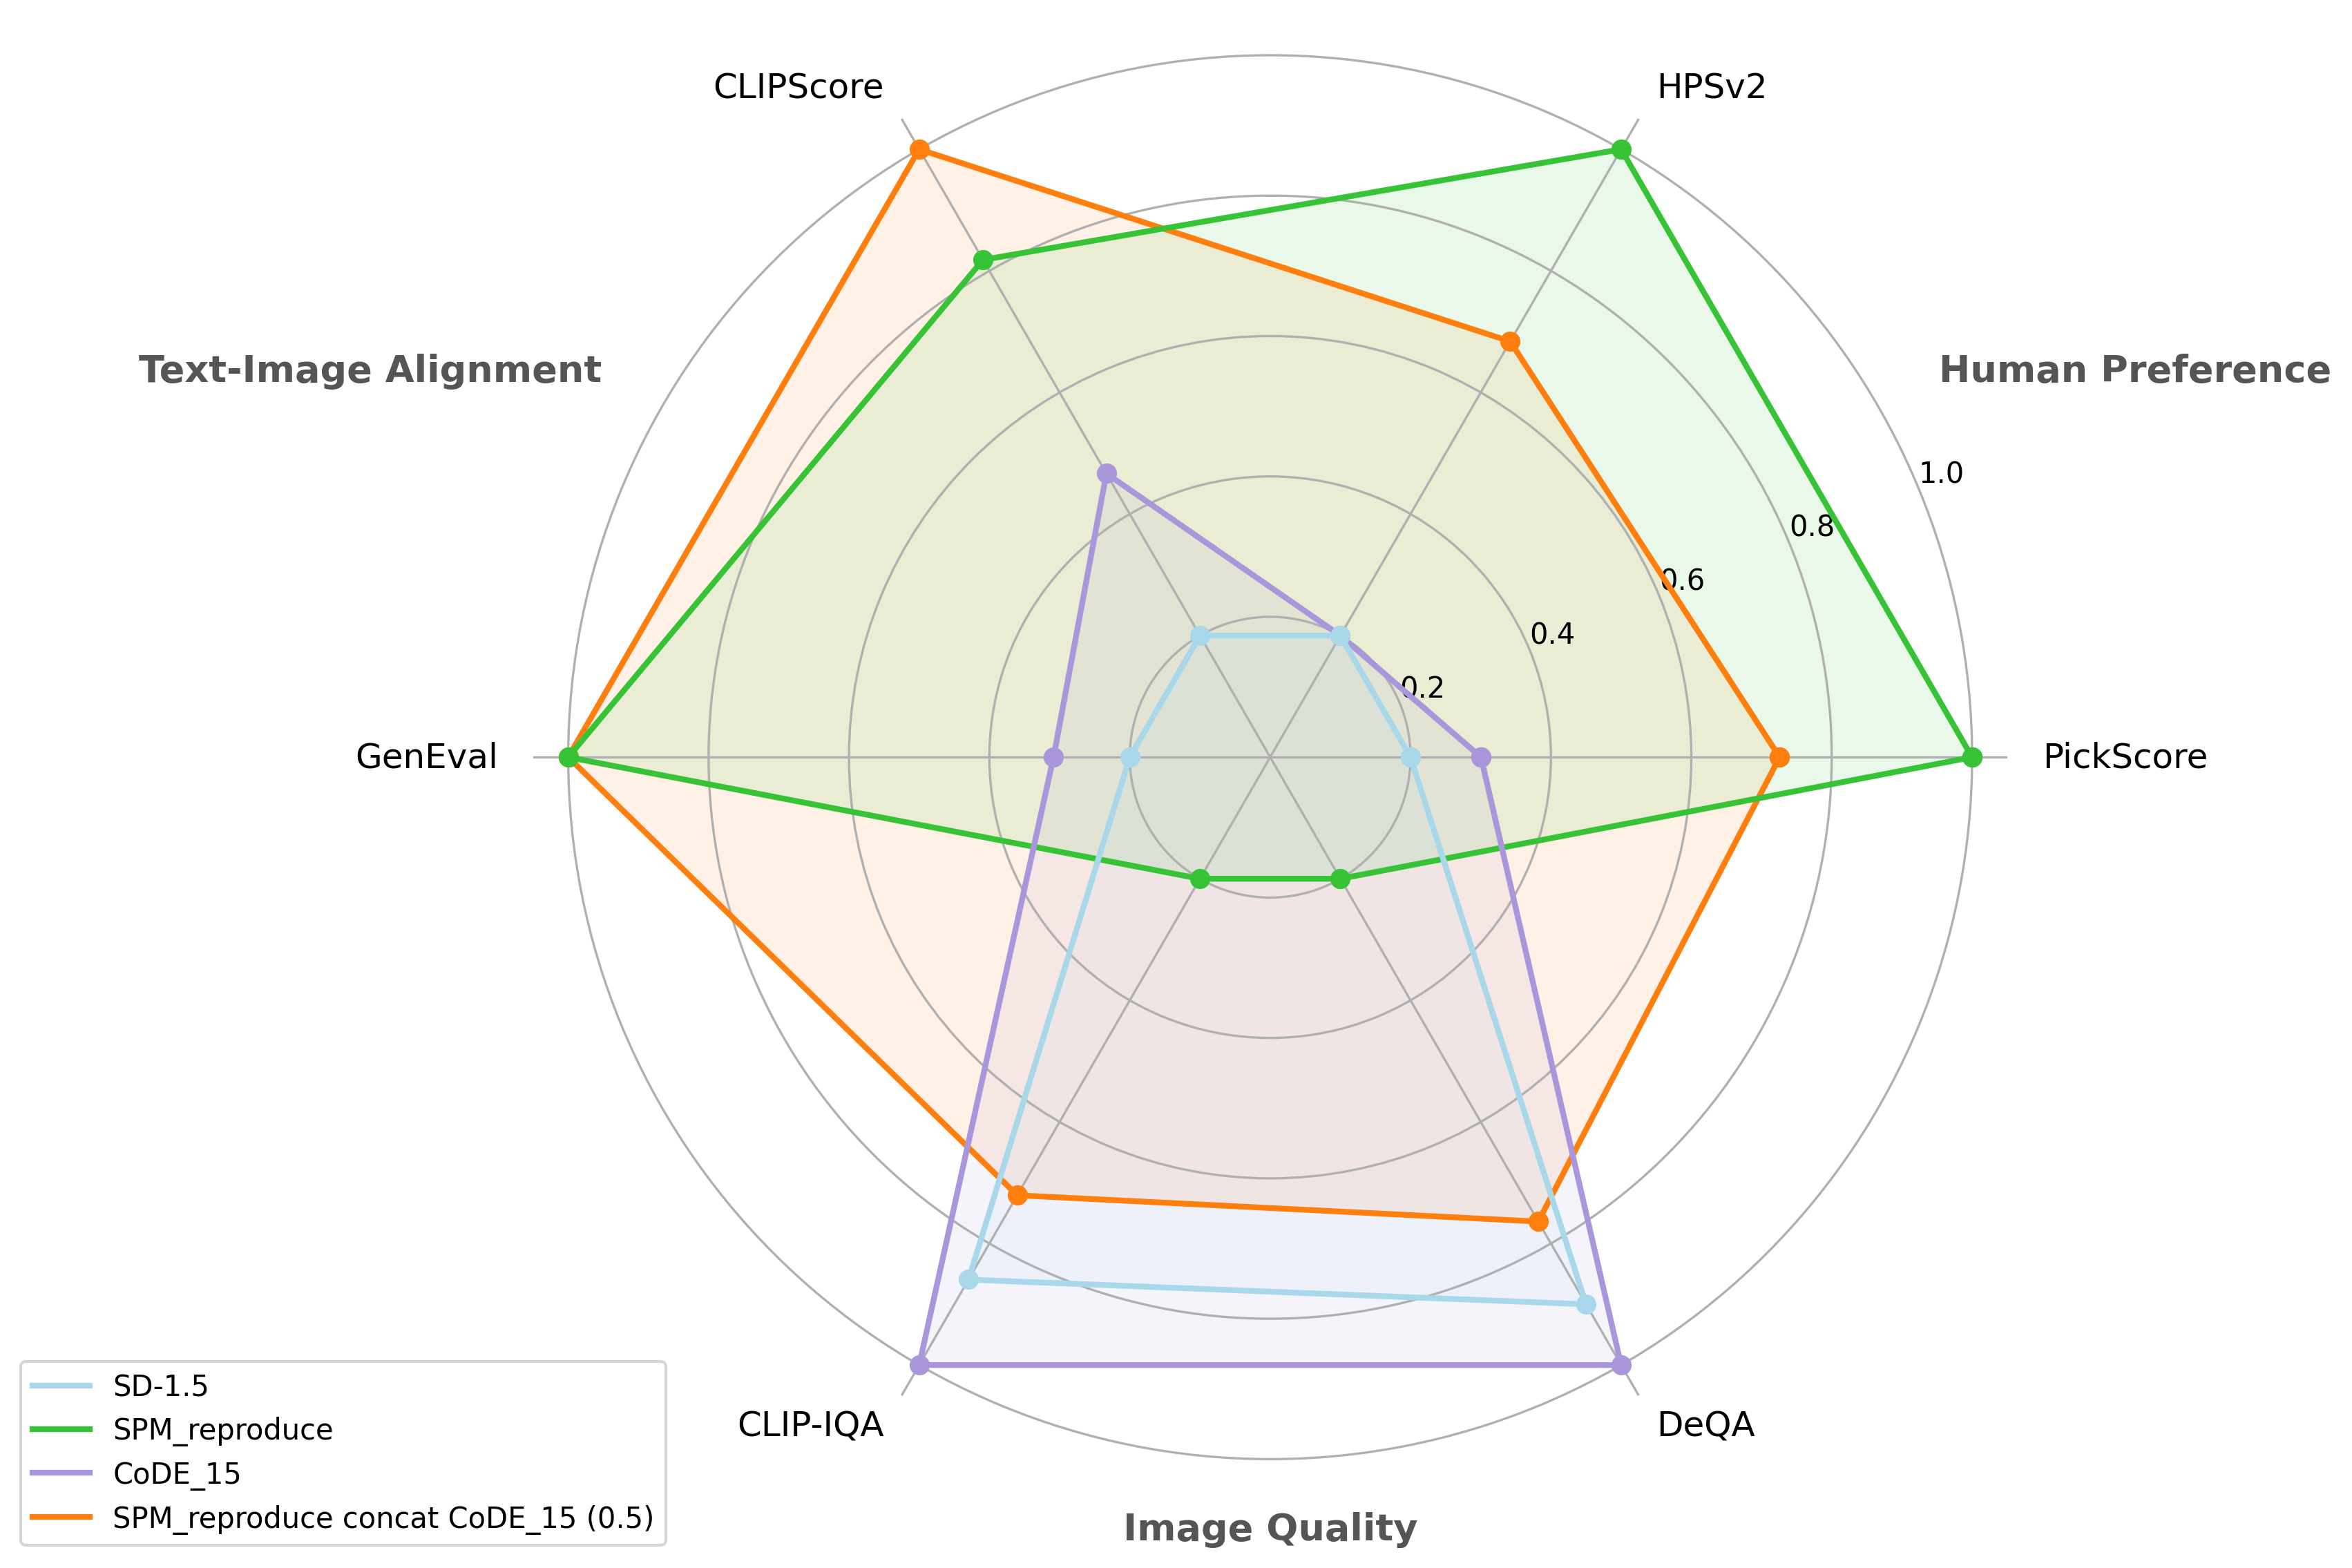

In [6]:
data = {
    "PickScore": [ data_dict[_]["PickScore"] for _ in methods ],
    "HPSv2": [ data_dict[_]["HPSv2"] for _ in methods ],
    "CLIPScore": [ data_dict[_]["CLIPScore"] for _ in methods ],
    "GenEval": [ data_dict[_]["GenEval"] for _ in methods ],
    "CLIP-IQA": [ data_dict[_]["CLIP-IQA"] for _ in methods ],
    "DeQA": [ data_dict[_]["DeQA"] for _ in methods ]
}

min_scale = 0.2

normalized_data = {}
for metric in metrics:
    metric_min, metric_max = min(data[metric]), max(data[metric])
    if metric_max == metric_min:
        normalized_data[metric] = [min_scale + (1-min_scale) * 0.5 for x in data[metric]]
    else:
        normalized_data[metric] = [min_scale + (1-min_scale)*((x-metric_min)/(metric_max-metric_min)) for x in data[metric]]

df = pd.DataFrame(normalized_data, index=methods)

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # 闭合雷达图

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True), dpi=300)

colors = ['#a8d8ea', "#36c436", '#aa96da', '#ff7f0e']
color_map = dict(zip(methods, colors))

# --- 新增代码：根据面积排序来解决覆盖问题 ---
# 1. 计算每个方法归一化分数的总和，作为其“面积”的代表
method_areas = {method: df.loc[method].sum() for method in methods}
# 2. 根据面积从大到小对方法进行排序
sorted_methods = sorted(method_areas, key=method_areas.get, reverse=True)

# --- 修改后的绘图循环：使用排序后的列表 ---
for i, method in enumerate(sorted_methods):
    alpha=0.1
    values = df.loc[method].values.tolist()
    values += values[:1]  # 闭合雷达图
    color = color_map[method] # 使用映射获取正确的颜色
    ax.plot(angles, values, 'o-', linewidth=2, label=method, color=color)
    if i == len(method) - 1:
        alpha=0.3
    ax.fill(angles, values, alpha=alpha, color=color)

# 设置雷达图的轴标签（指标名称）
ax.set_xticks(angles[:-1])
ax.set_xticklabels([])
ax.set_ylim(0, 1.05)

# Manually add labels at a greater distance and with rotation
for i, metric in enumerate(metrics):
    angle_rad = angles[i]
    label_distance = 1.1

    angle_deg = np.degrees(angle_rad)

    if angle_deg > 90 and angle_deg < 270:
        rotation_angle = 0
        ha = 'right'
    else:
        rotation_angle = 0
        ha = 'left'
        
    ax.text(angle_rad, label_distance, metric,
            ha=ha, va='center',
            fontsize=12,
            rotation=rotation_angle,
            rotation_mode="anchor")

# Add category labels
# Define the categories and their positions
categories = {
    "Human Preference": (angles[0] + angles[1]) / 2,  # Between PickScore and HPSv2
    "Text-Image Alignment": (angles[2] + angles[3]) / 2,  # Between CLIPScore and GenEval
    "Image Quality": (angles[4] + angles[5]) / 2,  # Between CLIP-IQA and DeQA
}

# Add category labels in a circular arc outside the metric labels
for category, angle_rad in categories.items():
    label_distance = 1.1  # Further out than metric labels
    angle_deg = np.degrees(angle_rad)
    
    if angle_deg > 90 and angle_deg < 270:
        rotation_angle = 0
        ha = 'right'
    else:
        rotation_angle = 0
        ha = 'left'
    
    if category == "Image Quality":
        ha = 'center'
    ax.text(angle_rad, label_distance, category,
            ha=ha, va='center',
            fontsize=13,
            fontweight='bold',
            color='#555555',
            rotation=rotation_angle,
            rotation_mode='anchor')


legend_handles = [Line2D([0], [0], color=color_map[m], lw=2, label=m) for m in methods]
ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.1, 0.1))


ax.grid(True)
ax.spines['polar'].set_visible(False)

plt.tight_layout()
plt.show()